In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd
from scipy import stats

df = pd.read_csv('../../Data/processed/cleaned_customer_data.csv')

Distribution ของ feature ระหว่าง Churned vs Not Churned ต่างกันไหม?

In [25]:
from scipy import stats

def test_numerical_feature(df, feature):
    churned = df[df["Churned"] == 1][feature]
    not_churned = df[df["Churned"] == 0][feature]
    
    # Mann-Whitney U Test
    stat, p = stats.mannwhitneyu(churned, not_churned)
    
    print(f"Feature: {feature}")
    print(f"p-value: {p:.6f}")
    
    # Median
    print(f"Median (Churned): {churned.median():.3f}")
    print(f"Median (Not Churned): {not_churned.median():.3f}")
    
    # Mean (optional)
    print(f"Mean (Churned): {churned.mean():.3f}")
    print(f"Mean (Not Churned): {not_churned.mean():.3f}")
    
    print("-"*40)

In [26]:
def cliffs_delta(x, y):
    nx = len(x)
    ny = len(y)
    return (np.sum(x[:, None] > y) - np.sum(x[:, None] < y)) / (nx * ny)

### Strong signals

In [28]:
test_numerical_feature(df, "Customer_Service_Calls")

Feature: Customer_Service_Calls
p-value: 0.000000
Median (Churned): 7.000
Median (Not Churned): 5.000
Mean (Churned): 6.896
Mean (Not Churned): 5.185
----------------------------------------


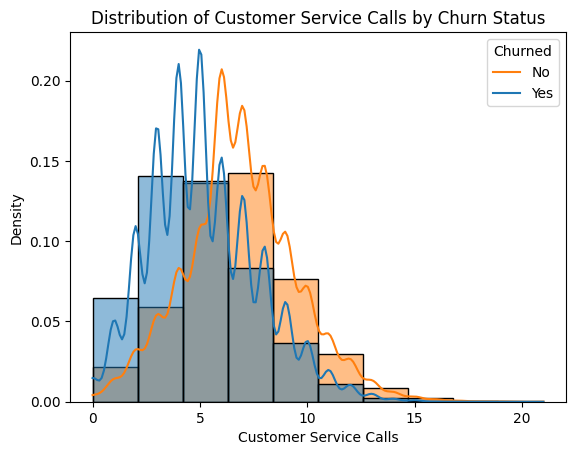

In [46]:
sns.histplot(data=df, x="Customer_Service_Calls", hue="Churned", kde=True, stat="density", common_norm=False, bins=10)
plt.title("Distribution of Customer Service Calls by Churn Status")
plt.xlabel("Customer Service Calls")
plt.ylabel("Density")
plt.legend(title="Churned", labels=["No", "Yes"])
plt.show()

- Customer_Service_Calls มีผลต่อ churned จริง และมี impact


In [29]:
df["Cart_Abandonment_Rate"].isnull().sum()

np.int64(0)

In [30]:
test_numerical_feature(df, "Cart_Abandonment_Rate")

Feature: Cart_Abandonment_Rate
p-value: 0.000000
Median (Churned): 66.600
Median (Not Churned): 55.500
Mean (Churned): 64.147
Mean (Not Churned): 54.155
----------------------------------------


- Cart_Abandonment_Rate มีผลต่อ churned จริง และมี impact

In [54]:
test_numerical_feature(df, "Days_Since_Last_Purchase")

Feature: Days_Since_Last_Purchase
p-value: 0.000000
Median (Churned): 24.000
Median (Not Churned): 21.000
Mean (Churned): 35.967
Mean (Not Churned): 26.541
----------------------------------------


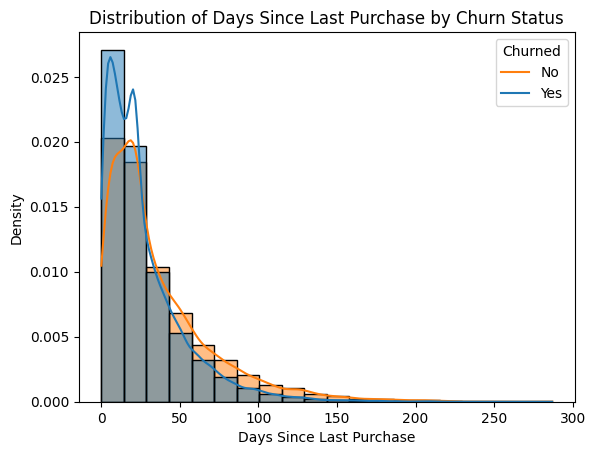

In [53]:
sns.histplot(data=df, x="Days_Since_Last_Purchase", hue="Churned", kde=True, stat="density", common_norm=False, bins=20)
plt.title("Distribution of Days Since Last Purchase by Churn Status")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Density")
plt.legend(title="Churned", labels=["No", "Yes"])
plt.show()

Moderate signals

    - Pages_Per_Session
    - Session_Duration_Avg
    - Login_Frequency

### Moderate signals

In [31]:
test_numerical_feature(df, "Pages_Per_Session")

Feature: Pages_Per_Session
p-value: 0.000000
Median (Churned): 7.200
Median (Not Churned): 8.700
Mean (Churned): 7.426
Mean (Not Churned): 9.242
----------------------------------------


In [32]:
test_numerical_feature(df, "Session_Duration_Avg")

Feature: Session_Duration_Avg
p-value: 0.000000
Median (Churned): 23.600
Median (Not Churned): 27.400
Mean (Churned): 23.988
Mean (Not Churned): 29.071
----------------------------------------


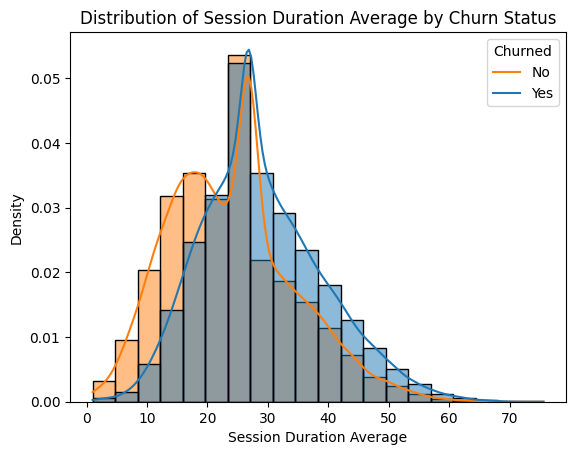

In [55]:
sns.histplot(data=df, x="Session_Duration_Avg", hue="Churned", kde=True, stat="density", common_norm=False, bins=20)
plt.title("Distribution of Session Duration Average by Churn Status")
plt.xlabel("Session Duration Average")
plt.ylabel("Density")
plt.legend(title="Churned", labels=["No", "Yes"])
plt.show()

In [33]:
test_numerical_feature(df, "Login_Frequency")

Feature: Login_Frequency
p-value: 0.000000
Median (Churned): 8.000
Median (Not Churned): 12.000
Mean (Churned): 9.121
Mean (Not Churned): 12.642
----------------------------------------


Weak signals

    - Total_Purchases
    - Days_Since_Last_Purchase
    - Wishlist_Items

### Weak signals

In [34]:
test_numerical_feature(df, "Total_Purchases")

Feature: Total_Purchases
p-value: 0.000000
Median (Churned): 10.000
Median (Not Churned): 13.000
Mean (Churned): 11.354
Mean (Not Churned): 13.833
----------------------------------------


Feature: Days_Since_Last_Purchase
p-value: 0.000000
Median (Churned): 24.000
Median (Not Churned): 21.000
Mean (Churned): 35.967
Mean (Not Churned): 26.541
----------------------------------------


In [36]:
test_numerical_feature(df, "Wishlist_Items")

Feature: Wishlist_Items
p-value: 0.000000
Median (Churned): 3.000
Median (Not Churned): 4.000
Mean (Churned): 3.364
Mean (Not Churned): 4.644
----------------------------------------


Minimal impact

    - Membership_Years
    - Payment_Method_Diversity
    - Average_Order_Value

### Minimal impact

In [37]:
test_numerical_feature(df, "Membership_Years")

Feature: Membership_Years
p-value: 0.796770
Median (Churned): 2.500
Median (Not Churned): 2.500
Mean (Churned): 2.982
Mean (Not Churned): 2.985
----------------------------------------


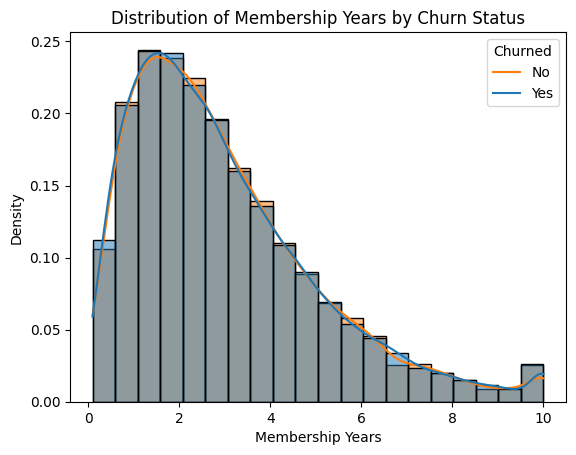

In [48]:
sns.histplot(data=df, x="Membership_Years", hue="Churned", kde=True, stat="density", common_norm=False, bins=20)
plt.title("Distribution of Membership Years by Churn Status")
plt.xlabel("Membership Years")
plt.ylabel("Density")
plt.legend(title="Churned", labels=["No", "Yes"])
plt.show()

In [38]:
test_numerical_feature(df, "Payment_Method_Diversity")

Feature: Payment_Method_Diversity
p-value: 0.449860
Median (Churned): 2.000
Median (Not Churned): 2.000
Mean (Churned): 2.344
Mean (Not Churned): 2.333
----------------------------------------


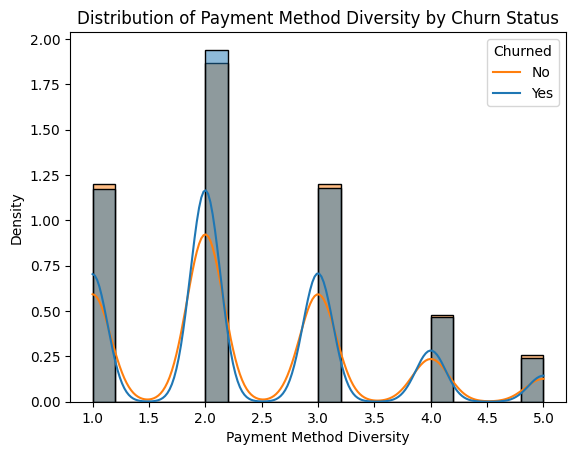

In [51]:
sns.histplot(data=df, x="Payment_Method_Diversity", hue="Churned", kde=True, stat="density", common_norm=False, bins=20)
plt.title("Distribution of Payment Method Diversity by Churn Status")
plt.xlabel("Payment Method Diversity")
plt.ylabel("Density")
plt.legend(title="Churned", labels=["No", "Yes"])
plt.show()

In [39]:
test_numerical_feature(df, "Average_Order_Value")

Feature: Average_Order_Value
p-value: 0.000000
Median (Churned): 124.395
Median (Not Churned): 108.935
Mean (Churned): 134.763
Mean (Not Churned): 118.384
----------------------------------------


Although Average Order Value shows a statistically significant difference,
the distributions are likely skewed with overlapping ranges.

This suggests that AOV has limited practical impact on churn prediction,
and may not be a strong standalone feature.

<Axes: xlabel='Average_Order_Value', ylabel='Density'>

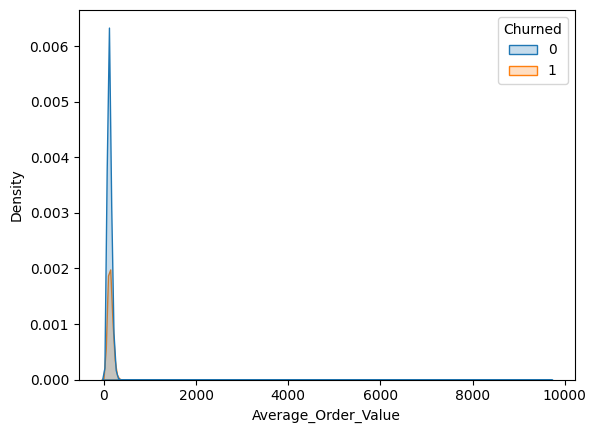

In [40]:
sns.kdeplot(data=df, x="Average_Order_Value", hue="Churned", fill=True)

<Axes: xlabel='Average_Order_Value', ylabel='Density'>

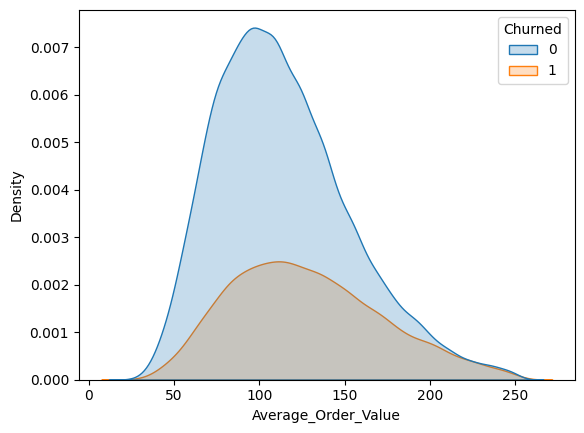

In [41]:
q99 = df["Average_Order_Value"].quantile(0.99)

filtered_df = df[df["Average_Order_Value"] <= q99]

sns.kdeplot(data=filtered_df, x="Average_Order_Value", hue="Churned", fill=True)